In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

# Tải dữ liệu Fashion-MNIST
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Chuẩn hóa
X_train = X_train / 255.0
X_test = X_test / 255.0

# Mô phỏng thêm 5 lớp dữ liệu tự thu thập
# 5 lớp mới được tạo bằng noise để minh hoạ
num_new_classes = 5
samples_per_new_class = 1000

X_new = np.random.rand(num_new_classes * samples_per_new_class, 28, 28)
y_new = np.repeat(np.arange(10, 15), samples_per_new_class)

# Gộp dữ liệu lại
X_train_all = np.concatenate([X_train, X_new], axis=0)
y_train_all = np.concatenate([y_train, y_new], axis=0)

# Shuffle
idx = np.random.permutation(len(X_train_all))
X_train_all, y_train_all = X_train_all[idx], y_train_all[idx]

# One-hot encoding
y_train_all_oh = to_categorical(y_train_all, 15)
y_test_oh = to_categorical(y_test, 15)

print("Kích thước train:", X_train_all.shape)
print("Kích thước test:", X_test.shape)
print("Số lớp:", y_train_all_oh.shape[1])


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Kích thước train: (65000, 28, 28)
Kích thước test: (10000, 28, 28)
Số lớp: 15


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(15, activation='softmax')  # Softmax output
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


C:\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 263,759 (1.01 MB)

 Trainable params: 263,759 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
history = model.fit(
    X_train_all, y_train_all_oh,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)


Epoch 1/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7321 - loss: 0.7135 - val_accuracy: 0.7958 - val_loss: 0.5161
Epoch 2/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8035 - loss: 0.4956 - val_accuracy: 0.8192 - val_loss: 0.4573
Epoch 3/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8176 - loss: 0.4563 - val_accuracy: 0.7771 - val_loss: 0.5724
Epoch 4/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8215 - loss: 0.4413 - val_accuracy: 0.8235 - val_loss: 0.4319
Epoch 5/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8324 - loss: 0.4135 - val_accuracy: 0.8395 - val_loss: 0.4052
Epoch 6/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8363 - loss: 0.3985 - val_accuracy: 0.8355 - val_loss: 0.4122
Epoch 7/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8403 - loss: 0.3883 - val_accuracy: 0.8386 - val_loss: 0.4089
Epoch 8/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8444 - loss: 0.3770 - val_ac

In [4]:
loss, acc = model.evaluate(X_test, y_test_oh)
print("Test accuracy:", acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8852 - loss: 0.3322
Test accuracy: 0.885200023651123


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


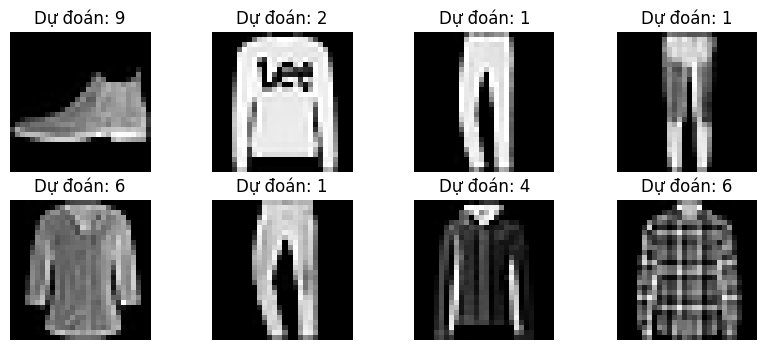

In [5]:
plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(X_test[i], cmap="gray")
    pred = np.argmax(model.predict(X_test[i].reshape(1,28,28)))
    plt.title(f"Dự đoán: {pred}")
    plt.axis("off")
plt.show()
